# CC-WBT-AI — Input Pipeline

Workflow: set inputs → write to files → run engine → read outputs

In [1]:
import sys, os
import openpyxl as _xl
from dotenv import load_dotenv
load_dotenv()
 
_cwd = os.path.abspath('')
if os.path.exists(os.path.join(_cwd, 'backend')):
    ROOT = _cwd
elif os.path.exists(os.path.join(_cwd, '..', 'backend')):
    ROOT = os.path.dirname(_cwd)
else:
    raise FileNotFoundError("Cannot find the backend folder")
 
BACKEND   = os.path.join(ROOT, 'backend')
NOTEBOOKS = os.path.join(ROOT, 'notebooks')
sys.path.insert(0, BACKEND)
sys.path.insert(0, NOTEBOOKS)

from pipeline_helpers import PipelineIO
from optimizer import run_optimization
print('Setup OK')

c:\Users\agarr\OneDrive\Escritorio\IIT\CC-WBT-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup OK


## 1. Model and technologies

In [2]:
COUNTRY    = 'Mozambique'
MODEL      = 'CleanStep'
TECHS      = ['Electricity', 'LPG']
START_YEAR = 2023
END_YEAR   = 2034
YEARS      = list(range(START_YEAR, END_YEAR + 1))
 
pio = PipelineIO(backend=BACKEND, country=COUNTRY, model=MODEL, techs=TECHS, start_year=START_YEAR, end_year=END_YEAR)
pio.ensure_model_exists()

  Copied fuel-financial-inputs.xlsx from template
  Copied carbon-credits.xlsx from template
Files to recreate from templates:
  design-capital-CleanStep.xlsx: does not exist
  technoeconomic-inputs-CleanStep.xlsx: does not exist
  financial-statements-CleanStep.xlsx: does not exist
  capex-fuels-CleanStep.xlsx: does not exist
  design-capital-CleanStep.xlsx
  technoeconomic-inputs-CleanStep.xlsx
  financial-statements-CleanStep.xlsx
  capex-fuels-CleanStep.xlsx
Model CleanStep ready.


## 2. Country-level inputs

In [3]:
# config
TAX_RATE  = 28
INFLATION = 5
 
# fuel financial inputs
FUEL_FIN = {
    'Electricity': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
    'LPG': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
}
 
# carbon credits (fuel-financial-inputs)
CC_CO2_CERT  = [0]*12
CC_LIQUIDITY = [0]*12
CC_PRICE_TON = [0]*12
CC_NUM_YEARS = 0
 
print('Country-level inputs defined.')

Country-level inputs defined.


## 3. Model-level inputs

In [4]:
# technoeconomic-inputs - Electricity (GRID/OFF-GRID)
TECHNO_ELEC = {
    'Electricity & E-Cooking': {
        'GRID': {
            'Demand':             [1473.6, 1616.8, 1793.2, 1954.5, 3101.6, 2235.1, 2355.9, 2518.5, 1659.5, 2786.4, 2900, 3001],
            'CAPEX - Growth':     [257.3,  324.6,  321.4,  318.2, 315, 311.8, 382, 451.1, 446.6, 442.1, 437.7, 290.8],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [48.2,   54.6,   62.2,   69.6, 77, 84.1, 91.1, 102.2, 112.7, 123, 133.1, 143],
            'D&A':                35,
        },
        'OFF-GRID': {
            'Demand':             [368.4, 379.3, 393.6, 400.3, 400.3, 394.4, 383.5, 376.3, 362.7, 344.4, 322.2, 296.8],
            'CAPEX - Growth':     [39.5,  50.3, 49.8, 49.3, 48.8, 48.4, 15.4, -17.1, -16.9, -16.8, -16.6, -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,  64.7, 74.9, 84.8, 94.5, 104, 113.4, 111.6, 105.1, 98.8, 92.6, 86.4],
            'D&A':                25,
        },
    },
    'Electricity (Low access)': {
        'GRID': {
            'Demand':              [1442.6, 1496.4, 1584.4, 1666.1, 1741.6, 1811.1, 1874.7, 1933.7, 1991.3, 2044.1, 2092.2, 2135.7],
            'CAPEX - Growth':      [214.8,   248.1,   245.6,   243.1,   240.7,   238.3,   276.1,   313.4,   310.3,   307.2,   304.1,   208.6],
            'CAPEX - Maintenance': [0]*12,
            'OPEX':                [46.2,    47.9,    50.9,    53.8,    56.7,    59.5,    62.2,    71,    81.3,    91.4,    101.3,   111  ],
            'D&A': 35,
        },
        'OFF-GRID': {
            'Demand':             [368.4,  379.3,  393.6,  400.3,  400.3,  394.4,  383.5,  376.3,  362.7,  344.4,  322.2,  296.8],
            'CAPEX - Growth':     [39.5,   50.3,   49.8,   49.3,   48.8,   48.4,   15.4,   -17.1,  -16.9,  -16.8,  -16.6,  -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,   64.7,   74.9,   84.8,   94.5,   104.0,  113.4,  111.6,  105.1,  98.8,   92.6,   86.5],
            'D&A': 25,
        },
    },
}
 
# technoeconomic-inputs — LPG (other fuels)
TECHNO_LPG = {
    'Demand':             [301.9,  326.6,  438.7,  539.3,  629.3,  709.6,  780.8,  970.5,  949.4,  928.2,  906.8,  885.4],
    'CAPEX - Growth':     [2.7,    4.8,    4.8,    4.7,    4.7,    4.7,    3.7,    2.6,    2.6,    2.6,    2.6,    2.5],
    'CAPEX - Maintenance':[0]*12,
    'OPEX':               [25.5,   36.4,   51.4,   66.3,   81.2,   96.0,   110.8,  115.4,  118.1,  120.7,  123.4,  126.0],
    'D&A': 15,
}
 
# tariffs & upstreams
TARIFFS = {
    'Electricity': [0.15, 0.16, 0.17, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.26],
    'LPG':         [0.08, 0.08, 0.08, 0.09, 0.09, 0.10, 0.10, 0.11, 0.11, 0.12, 0.12, 0.13],
}
UPSTREAMS = {
    'Electricity': [0]*12,
    'LPG':         [0]*12,
}
 
# CO2 emitted (carbon-credits)
CO2_BASELINE = [21.61, 20.602, 19.838, 19.074, 18.311, 17.547, 16.783, 16.436, 16.367, 16.298, 16.229, 16.160]
CO2_EMITTED = [21.611, 19.405, 17.428, 15.452, 13.475, 11.498, 9.521, 9.105, 9.190, 9.275, 9.360, 9.446]
 
print('Model-level inputs defined.')

Model-level inputs defined.


### Capital Structure Optimisation
Optuna searches for the combination of equity/grants/debt/costs that minimises total debt (or long-term subsidies) across the planning horizon. `SEARCH_RANGES` defines the search space and `OBJECTIVE` controls what is minimised.

In [5]:
SEARCH_RANGES = {
    'pct_equity':          (0.10, 0.50),
    'pct_grants':          (0.10, 0.60), #60
    'cost_equity':         (0.08, 0.20),
    'cost_debt':           (0.04, 0.12),
    'years_realisation':   (4, 10),
    'grace_period':        (1, 6),
    'amortization_period': (5, 30),
}
OBJECTIVE = 'debt'   # 'debt'/'lts
N_TRIALS  = 100

CAPITAL_STRUCTURE = {}
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"Optimising {tech}...")
    CAPITAL_STRUCTURE[tech] = run_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        fuel_fin=FUEL_FIN,
        tariffs=TARIFFS,
        fuel_key='Electricity',
        search_ranges=SEARCH_RANGES,
        objective=OBJECTIVE,
        n_trials=N_TRIALS,
    )
    print(f"  → {CAPITAL_STRUCTURE[tech]}")

print("Optimising LPG...")
CAPITAL_STRUCTURE['LPG'] = run_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    fuel_fin=FUEL_FIN,
    tariffs=TARIFFS,
    fuel_key='LPG',
    search_ranges=SEARCH_RANGES,
    objective=OBJECTIVE,
    n_trials=N_TRIALS,
)
print(f"  → {CAPITAL_STRUCTURE['LPG']}")

for sheet, cs in CAPITAL_STRUCTURE.items():
    print(f"\n{sheet}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  CAPEX  " + "".join(f"{round(v,1):>10}" for v in cs.get('CAPEX_SCHEDULE', [])))
    print("  DEBT   " + "".join(f"{round(v,1):>10}" for v in cs.get('DEBT_INCREASE',  [])))
    print("  LTS    " + "".join(f"{round(v,1):>10}" for v in cs.get('LT_SUBSIDY_SCHEDULE', [])))

Optimising Electricity & E-Cooking...
K1=0.27, K2=0.068
Trial 0: total debt=3e+01, debt=[0, 0, 0, 0, 0, 0, 0, 32.51595765800515, 0, 0, 0, 0], capex=[185.94815166682088, 214.20727354576763, 249.96597285044382, 260.39323574504573, 304.1443019538376, 349.41123806653695, 399.7378526637889, 541.4309989556573, 601.1524805634405, 422.84042836889336, 471.08657812874634, 530.6814874910214], lt_subsidies=[0, 0, 6.086143837312927e-13, 1.8960437814352424e-13, -7.433969727501942e-14, 4.8858388640225816e-14, -9.944118452021677e-13, 19.703451282729137, 46.57892089808217, 51.56054109198542, 58.17171459742048, 46.8890080277453]
Trial 1: total debt=4e+01, debt=[0, 0, 0, 0, 0, 36.902045230950144, 0, 0, 0, 0, 0, 0], capex=[173.33514298930703, 181.95798281902063, 210.80703987217308, 217.9218088631979, 252.73183438707022, 346.87616504403945, 371.2305697896844, 464.59231542204395, 581.2629635282689, 493.20751138971457, 570.689391813043, 666.387274082438], lt_subsidies=[0, 0, 0, 0, 0, 6.820611607349337, 31.29

## 4. Write inputs

In [6]:
print('=== COUNTRY-LEVEL ===')
pio.write_config_scalar('TAX_RATES',  TAX_RATE)
pio.write_config_scalar('INFLATIONS', INFLATION)
 
for fuel, vals in FUEL_FIN.items():
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Expected non-technical losses',        vals['NTL'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade receivables - Days of revenues', vals['DAYS_REC'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade payables - Days of OPEX costs',  vals['DAYS_PAY'])
 
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'CO2 certificate (%) - from the total CO2 avoided', CC_CO2_CERT)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Liquidity',     CC_LIQUIDITY)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Price per TON', CC_PRICE_TON)
pio.write_timeseries_first_year(pio.carbon_credits_path, 'Carbon Credits', 'Number of years that you could sell those carbon credits', CC_NUM_YEARS)
 
print('=== MODEL-LEVEL ===')
for sheet, cs in CAPITAL_STRUCTURE.items():
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])
 
for sheet, systems in TECHNO_ELEC.items():
    for system, params in systems.items():
        for param, values in params.items():
            if param == 'D&A': pio.write_techno_da(sheet, system, values)
            else:               pio.write_techno_list(sheet, system, param, values)
 
for param, values in TECHNO_LPG.items():
    if param == 'D&A': pio.write_techno_nosystem_da('LPG', values)
    else:               pio.write_techno_nosystem_list('LPG', param, values)
 
for tech, vals in TARIFFS.items():
    pio.write_config_timeseries('TARIFFS',   tech, YEARS, vals)
for tech, vals in UPSTREAMS.items():
    pio.write_config_timeseries('UPSTREAMS', tech, YEARS, vals)
 
pio.write_carbon_row('CO2 emited - Baseline scenario', CO2_BASELINE)
pio.write_carbon_co2_emitted(CO2_EMITTED, YEARS)
print('\nAll inputs written.')

=== COUNTRY-LEVEL ===
  config.json -> TAX_RATES = 28
  config.json -> INFLATIONS = 5
  fuel-financial-inputs.xlsx / Electricity -> Expected non-technical losses
  fuel-financial-inputs.xlsx / Electricity -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / Electricity -> Trade payables - Days of OPEX costs
  fuel-financial-inputs.xlsx / LPG -> Expected non-technical losses
  fuel-financial-inputs.xlsx / LPG -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / LPG -> Trade payables - Days of OPEX costs
  carbon-credits.xlsx / Carbon Credits -> CO2 certificate (%) - from the total CO2 avoided
  carbon-credits.xlsx / Carbon Credits -> Liquidity
  carbon-credits.xlsx / Carbon Credits -> Price per TON
  carbon-credits.xlsx / Carbon Credits -> Number of years that you could sell those carbon credits (first year)
=== MODEL-LEVEL ===
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 20
  design-capital-CleanStep.xlsx / Electricity & E

## 5. Run engine

In [7]:
print('Running engine...')
df_conv = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
print('Done.')

Running engine...
  Converged in 14 iterations.
Done.


In [8]:
df_conv

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::Electricity & E-Cooking::Cash Flow from Assets,FS::LPG::Long term subsidies,FS::LPG::Annual Cost of Service,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-2.952689e-12,...,-4582.618740,251.703857,1137.784857,0.895726,-42.104274,0.000000,3892.408534,-35.749315,-3418.449315,NaN
1,2,2160.003151,432.000630,1144.801670,0.0,13.0,2329.363014,722.102534,698.808904,-2.952689e-12,...,-1507.800512,258.083596,1144.164596,23.176533,-19.823467,0.000000,4365.220809,2379.639477,-1003.060523,3.074818e+03
2,3,1019.579451,203.915890,540.377109,0.0,13.0,1019.455306,316.031145,305.836592,-2.952689e-12,...,-1507.800512,262.680615,1148.761615,29.556272,-13.443728,6.748228,4727.428037,2379.639477,-1003.060523,1.309908e+03
3,4,1019.579451,203.915890,540.377109,0.0,13.0,1019.455306,316.031145,305.836592,-2.952689e-12,...,-1465.933124,267.262042,1153.343042,34.153291,-8.846709,110.171243,5058.883466,2386.387705,-996.312295,3.784300e+02
4,5,1018.194412,203.638882,539.643039,0.0,13.0,1012.707077,313.939194,303.812123,-2.952689e-12,...,-1390.037044,271.793042,1157.874042,38.734718,-4.265282,271.944583,5357.921323,2489.810719,-892.889281,3.355783e+02
5,6,980.771498,196.154300,519.808894,0.0,13.0,909.284063,281.878060,272.785219,-2.952689e-12,...,-1260.210784,276.238884,1162.319884,43.265718,0.265718,467.900445,5622.878152,2651.584060,-731.115940,2.905967e+02
6,7,941.553849,188.310770,499.023540,0.0,13.0,758.660749,235.184832,227.598225,-2.952689e-12,...,-1070.944623,280.347903,1166.428903,47.711560,4.711560,663.098445,5853.233409,2847.539922,-535.160078,2.487864e+02
7,8,904.130934,180.826187,479.189395,0.0,13.0,639.000006,198.090002,191.700002,-2.952689e-12,...,-886.358499,283.870022,1169.951022,51.820579,8.820579,855.721374,6048.431409,3042.737922,-339.962078,2.103133e+02
8,9,904.130934,180.826187,479.189395,0.0,13.0,628.898491,194.958532,188.669547,-2.952689e-12,...,-716.396201,286.741821,1172.822821,55.342698,12.342698,1014.030432,6206.740466,3235.360851,-147.339149,1.926229e+02
9,10,904.130934,180.826187,479.189395,0.0,13.0,628.898491,194.958532,188.669547,-2.952689e-12,...,-557.776426,288.900667,1174.981667,58.214497,15.214497,1133.691174,6326.401209,3393.669909,10.969909,1.586198e+02


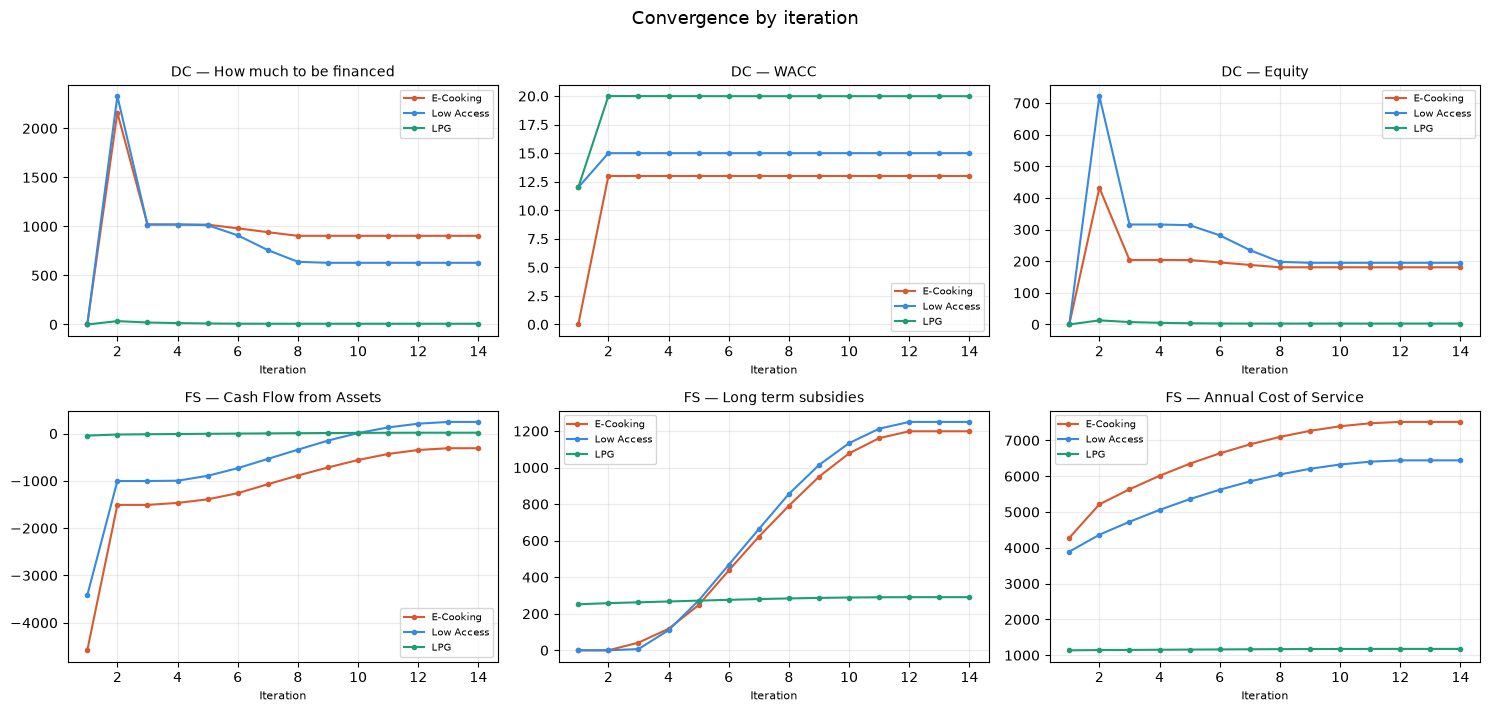

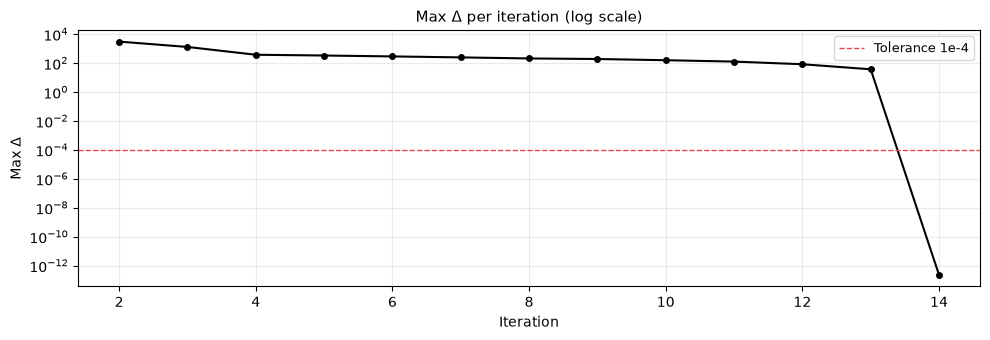

In [9]:
pio.plot_convergence(df_conv)

### Debt requirements

The platform calculates the annual debt needed to cover negative cash positions. 
Review below and optionally inject it back into the model before re-running.

In [10]:
print("=== REQUIRED DEBT PER TECHNOLOGY ===")
REQUIRED_DEBT = {}
for SHEET in pio.get_expanded_sheets():
    req = pio.read_required_debt(SHEET)
    REQUIRED_DEBT[SHEET] = req
    print(f"\n{SHEET}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  " + "".join(f"{round(v,1):>10}" for v in req))

=== REQUIRED DEBT PER TECHNOLOGY ===

Electricity & E-Cooking
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

Electricity (Low access)
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0      25.4      37.0       0.9       0.0       0.0       0.0       0.0       0.0       0.0       0.0

LPG
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0


In [11]:
USE_REQUIRED_DEBT = False   # True = automatically inject platform-calculated debt
DEBT_OVERRIDE     = None   # Or: {'Electricity & E-Cooking': [0, 34, 96, 0, ...]}
MAX_DEBT_ITER     = 8 
DEBT_TOL          = 0.5

accumulated = {
    sheet: list(CAPITAL_STRUCTURE[sheet].get('DEBT_INCREASE', [0]*len(YEARS)))
    for sheet in pio.get_expanded_sheets()
}

if DEBT_OVERRIDE:
    for sheet, vals in DEBT_OVERRIDE.items():
        accumulated[sheet] = list(vals)

if USE_REQUIRED_DEBT or DEBT_OVERRIDE:
    print("=== DEBT CONVERGENCE LOOP ===")
    df_conv2 = None
    for debt_iter in range(MAX_DEBT_ITER):
        total_needed = 0
        for sheet in pio.get_expanded_sheets():
            req = pio.read_required_debt(sheet)
            total_needed += sum(req)
            for t, v in enumerate(req):
                if t < len(accumulated[sheet]):
                    accumulated[sheet][t] += v

        print(f"  Iter {debt_iter+1}: remaining debt needed = {total_needed:.2f} M$")

        if total_needed < DEBT_TOL:
            print(f"  Converged in {debt_iter+1} iteration(s).")
            break

        for sheet, vals in accumulated.items():
            pio.write_design_debt_list(sheet, vals)
            CAPITAL_STRUCTURE[sheet]['DEBT_INCREASE'] = vals

        df_conv2 = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
    else:
        print(f"  Warning: did not converge after {MAX_DEBT_ITER} iterations.")

    if df_conv2 is not None:
        display(df_conv2)

    print("\n=== FINAL INJECTED DEBT PER TECHNOLOGY ===")
    for sheet, vals in accumulated.items():
        print(f"\n{sheet}")
        print("  " + "".join(f"{y:>10}" for y in YEARS))
        print("  " + "".join(f"{round(v,1):>10}" for v in vals))
else:
    print("No debt injection applied.")

No debt injection applied.


## 6. Outputs

In [12]:
col_w = 10
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue
    print(f"\n{'='*70}")
    print(f"  {SHEET}")
    print('='*70)
    header = f"{'Row':<35}" + ''.join(f"{y:>{col_w}}" for y in YEARS)
    print(header)
    print('-' * len(header))
    for key, values in out.items():
        print(f"{key:<35}" + ''.join(f"{round(v,1):>{col_w}}" for v in values))
    check_vals = out.get('Check', [0]*len(YEARS))
    if any(abs(v) > 1 for v in check_vals):
        print(f"\n  ⚠  Balance sheet check FAILED: {[round(v,1) for v in check_vals]}")
    else:
        print(f"\n  ✓  Balance sheet OK")


  Electricity & E-Cooking
Row                                      2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Long term subsidies                         0         0         0      38.8         0      76.6     120.3     141.2     289.3     189.3     184.6     158.6
EBITDA                                  315.5     382.8     412.8     459.5     620.1     554.1     436.3     504.9     494.1     651.5     693.5     743.8
Net Income                              264.8     316.7     329.7     365.7     462.0     427.6     293.2     339.7     364.7     441.4     461.9     484.8
Annual Cost of Service                  220.4     287.2     369.3     439.1     588.9     576.2     668.2     749.1     734.2     909.4     957.9    1016.0
Check                                

In [13]:
# === COMPARISON: PYOMO vs PLATFORM ===
col_w = 9

k1_annual = [cs['TARIFF_INCOME'][t] / cs['CAPEX_SCHEDULE'][t] 
             if cs['CAPEX_SCHEDULE'][t] != 0 else 0 
             for t in range(len(YEARS))]
print("  K1 anual: " + ''.join(f"{round(v,3):>9}" for v in k1_annual))

COMP_VARS = [
    ('Tariff Income',        'TARIFF_INCOME',        'Annual Cost of Service'),  # plataforma no tiene tariff directo, usamos ACoS como proxy
    ('Grants',               'GRANTS_PYOMO',         'GRANTS:- Realisation'),
    ('LT Subsidies',         'LT_SUBSIDY_SCHEDULE',  'Long term subsidies'),
    ('Revenues',             'REVENUES_PYOMO',        None),
    ('Costs',                'COSTS_PYOMO',           None),
    ('EBITDA',               'EBITDA_PYOMO',          'EBITDA'),
    ('ACoS',                 None,                    'Annual Cost of Service'),  # añadir ACoS plataforma
    ('Financial Expenses',   'FINANCIAL_EXP_PYOMO',   'Financial Expense'),
    ('CFA',                  'CFA_PYOMO',             'Cash Flow from Assets'),
    ('Debt Increase',        'DEBT_INCREASE',         'DEBT:+ Increase'),
    ('CAPEX (Pyomo)',        'CAPEX_SCHEDULE',         None),
    ('ACoS', 'ACOS_PYOMO', 'Annual Cost of Service'),
]

for sheet in pio.get_expanded_sheets():
    cs  = CAPITAL_STRUCTURE[sheet]
    out = pio.read_outputs(sheet)

    print(f"\n{'='*80}")
    print(f"  {sheet}  —  K1={cs['K1']:.3f}, K2={cs['K2']:.3f}")
    print(f"{'='*80}")

    # CAPEX real del technoeconomic (plataforma)
    if sheet == 'LPG':
        capex_real = TECHNO_LPG.get('CAPEX - Growth', [0]*len(YEARS))
    else:
        g  = TECHNO_ELEC[sheet].get('GRID',     {}).get('CAPEX - Growth', [0]*len(YEARS))
        og = TECHNO_ELEC[sheet].get('OFF-GRID', {}).get('CAPEX - Growth', [0]*len(YEARS))
        capex_real = [g[t]+og[t] for t in range(len(YEARS))]

    print("  CAPEX Platform: " + ''.join(f"{round(v,1):>9}" for v in capex_real))
    print("  CAPEX Pyomo:    " + ''.join(f"{round(v,1):>9}" for v in cs['CAPEX_SCHEDULE']))
    print()

    print(f"{'Variable':<25} {'Source':<10}" + ''.join(f"{y:>{col_w}}" for y in YEARS) + f"{'TOTAL':>{col_w}}")
    print('-'*80)

    for name, pyomo_key, platform_key in COMP_VARS:
        if pyomo_key and pyomo_key in cs:
            vals = cs[pyomo_key]
            tot  = round(sum(vals), 1)
            print(f"{name:<25} {'Pyomo':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if platform_key and platform_key in out:
            vals = out[platform_key]
            tot  = round(sum(vals), 1)
            print(f"{'':<25} {'Platform':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if pyomo_key or platform_key:
            print()

  K1 anual:   766.574 1693.349 1163.847   19.837   36.733   12.508   14.154    8.081    8.152   15.014   17.504   14.802

  Electricity & E-Cooking  —  K1=0.267, K2=0.068
  CAPEX Platform:     296.8    374.9    371.2    367.5    363.8    360.2    397.4    434.0    429.7    425.3    421.1    289.1
  CAPEX Pyomo:        245.2    299.9    356.3    378.5    450.1    609.1    277.4    308.2    341.6    377.8    401.6    485.3

Variable                  Source         2023     2024     2025     2026     2027     2028     2029     2030     2031     2032     2033     2034    TOTAL
--------------------------------------------------------------------------------
Tariff Income             Pyomo         311.4    345.0    382.7    399.9    445.0    500.6    541.8    586.2    634.1    686.1    741.7    837.2   6411.7
                          Platform      220.4    287.2    369.3    439.1    588.9    576.2    668.2    749.1    734.2    909.4    957.9   1016.0   7516.0

Grants                    Pyom

## 7. Summary metrics

In [14]:
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue

    lts      = out.get('Long term subsidies',  [0]*len(YEARS))
    equity   = out.get('Equity - EoP',         [0]*len(YEARS))
    debt_eop = out.get('DEBT:EoP',             [0]*len(YEARS))
    grants   = out.get('GRANTS:- Realisation', [0]*len(YEARS))

    _wb = _xl.load_workbook(pio.design_cap_path, data_only=True)
    _ws = _wb[SHEET]
    wacc = next(
        (row[2].value for row in _ws.iter_rows(max_col=3) if row[0].value == 'WACC'),
        None
    )
    _wb.close()

    total_lts    = round(sum(lts), 1)
    total_grants = round(sum(abs(v) for v in grants), 1)
    peak_equity  = round(max(equity), 1)
    peak_debt    = round(max(abs(v) for v in debt_eop), 1)

    print(f"\n{SHEET}")
    print(f"  WACC:               {wacc:.2f}%")
    print(f"  Total LTS:          {total_lts} M$")
    print(f"  Total grants:       {total_grants} M$")
    print(f"  Peak equity (EoP):  {peak_equity} M$")
    print(f"  Peak debt (EoP):    {peak_debt} M$")


Electricity & E-Cooking
  WACC:               13.00%
  Total LTS:          1198.7 M$
  Total grants:       1131.2 M$
  Peak equity (EoP):  4119.7 M$
  Peak debt (EoP):    0 M$

Electricity (Low access)
  WACC:               15.00%
  Total LTS:          1249.9 M$
  Total grants:       691.4 M$
  Peak equity (EoP):  3130.6 M$
  Peak debt (EoP):    0.0 M$

LPG
  WACC:               19.99%
  Total LTS:          290.8 M$
  Total grants:       20.5 M$
  Peak equity (EoP):  42.3 M$
  Peak debt (EoP):    0.0 M$


## 8. AI Layer — RL Optimisation + LLM

In [17]:
from rl_agent import run_rl_optimization, load_agent, save_agent, log_run
from llm_layer import explain_results

### 8.1 RL Optimisation

In [18]:
N_ROUNDS = 20
N_TRIALS_PER_ROUND = 5
 
RL_RESULTS = {}
RL_HISTORIES = {}
 
# NEW: load the agent trained in the previous execution, if any
shared_agent, shared_optimizer, loaded = load_agent()
print(f"Loaded previously-trained agent: {loaded}")
 
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"\n=== RL: {tech} ===")
    best, history, shared_agent, shared_optimizer = run_rl_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        initial_ranges=SEARCH_RANGES,
        fuel_fin=FUEL_FIN,
        fuel_key='Electricity',
        objective=OBJECTIVE,
        n_rounds=N_ROUNDS,
        n_trials_per_round=N_TRIALS_PER_ROUND,
        tariffs=TARIFFS,
        agent=shared_agent,
        optimizer_=shared_optimizer,
    )
    RL_RESULTS[tech] = best
    RL_HISTORIES[tech] = history
 
print("\n=== RL: LPG ===")
best, history, shared_agent, shared_optimizer = run_rl_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    initial_ranges=SEARCH_RANGES,
    fuel_fin=FUEL_FIN,
    fuel_key='LPG',
    objective=OBJECTIVE,
    n_rounds=N_ROUNDS,
    n_trials_per_round=N_TRIALS_PER_ROUND,
    tariffs=TARIFFS,
    agent=shared_agent,
    optimizer_=shared_optimizer,
)
RL_RESULTS['LPG'] = best
RL_HISTORIES['LPG'] = history

save_agent(shared_agent, shared_optimizer)
log_run(run_label="notebook_run", results=RL_RESULTS, histories=RL_HISTORIES)

Loaded previously-trained agent: False

=== RL: Electricity & E-Cooking ===

── RL Round 1/20 ──
K1=0.27, K2=0.068
Trial 0: total debt=0, debt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[287.7340112493543, 355.86272331929973, 427.6594835821605, 459.8766362488491, 553.1342064529506, 656.0354908765285, 511.76744902286265, 0, 0, 377.1424410859726, 416.46288477978663, 485.3246733822409], lt_subsidies=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Trial 1: total debt=0, debt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[229.95213151739546, 280.0341505287363, 331.39170145382957, 350.469833930356, 491.0338605840553, 275.639910828882, 312.66277299172344, 326.6204968813129, 396.57495101565655, 448.82342160597, 507.6474985517239, 580.1492701103668], lt_subsidies=[0, 0, 0, 0, 34.9681703536172, 40.43630351306924, 48.200992357995176, 31.2584273999737, 66.05048595617679, 79.46362799794133, 95.12310371312265, 94.4669818371558]
Trial 2: total debt=2e+02, debt=[0, 0, 0, 201.99067202151227, 0, 0, 0, 0, 0, 0, 0, 0

### 8.2 Write RL results and re-run engine

In [21]:
for sheet, cs in RL_RESULTS.items():
    if cs is None:
        continue
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])

df_rl = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
display(df_rl)

  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 26
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Equity = 16
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 2. Grants = 60
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Years realisation = 9
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Debt = 5
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Grace period = 2
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Amortization period = 30
  design-capital / Electricity & E-Cooking -> User-defined debt increase
  design-capital-CleanStep.xlsx / Electricity (Low access) -> 1. Equity = 41
  design-capital-CleanStep.xlsx / Electricity (Low access) -> Cost of Equity = 19
  design-capital-CleanStep.xlsx / Electricity (Low access) -> 2. Grants = 53
  design-capital-CleanStep.xlsx / Electricity (Low access) -> Years realisation = 9
  design-capital-CleanStep.xlsx / Electricity (Lo

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::Electricity & E-Cooking::Cash Flow from Assets,FS::LPG::Long term subsidies,FS::LPG::Annual Cost of Service,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,945.585711,245.852285,567.351427,0.0,16.0,628.898491,257.848382,333.316200,-1.132927e-13,...,-309.115323,284.521591,1170.602591,62.240346,19.240346,1985.892814,7209.592769,3629.542851,246.842851,NaN
1,2,945.585711,245.852285,567.351427,0.0,16.0,628.898491,257.848382,333.316200,-1.132927e-13,...,366.259130,284.521591,1170.602591,55.994267,12.994267,1985.892814,7209.592769,4365.532291,982.832291,7.359894e+02
2,3,783.567110,203.727449,470.140266,0.0,16.0,500.018469,205.007572,265.009788,-1.132927e-13,...,366.259130,284.521591,1170.602591,55.994267,12.994267,1985.892814,7209.592769,4365.532291,982.832291,1.620186e+02
3,4,783.567110,203.727449,470.140266,0.0,16.0,500.018469,205.007572,265.009788,-1.132927e-13,...,366.259130,284.521591,1170.602591,55.994267,12.994267,1985.892814,7209.592769,4365.532291,982.832291,4.547474e-13


### 8.3 LLM Explanation

In [22]:
from dotenv import load_dotenv
load_dotenv(override=True)

outputs_rl = {sheet: pio.read_outputs(sheet) for sheet in pio.get_expanded_sheets()}

pattern_results = {}
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    lts_sched  = cs.get('LT_SUBSIDY_SCHEDULE', [0]*len(YEARS))
    debt_sched = cs.get('DEBT_INCREASE',        [0]*len(YEARS))
    total_lts  = cs.get('TOTAL_LT_SUBSIDIES',   0)
    pattern_results[sheet] = {
        'subsidy_dependent': min(total_lts / 5000, 1.0),
        'fragile_structure': sum(1 for v in debt_sched if v > 0) / len(YEARS),
        'high_circularity':  0.0,
    }

explanation = explain_results(pattern_results, outputs_rl, YEARS, COUNTRY, language='en', model='openai/gpt-oss-20b')
print(explanation)

The CleanStep pipeline shows that both the electricity‑plus‑e‑cooking and low‑access electricity portfolios can be financed without any debt leverage – peak debt is zero – yet they require a substantial minimum cash cushion (≈ 173 M$) and carry an average cost of capital of 688–601 M$ per year. The LPG module is far smaller in total long‑term support (284 M$) but its annual ACoSt (97.6 M$) is disproportionately high relative to its size, signalling a higher risk premium. No flags were triggered, meaning the models do not exhibit subsidy dependence, fragile structures or convergence problems, but the elevated ACoSt for the electricity assets underscores the need for low‑cost debt or equity to keep financing costs acceptable. Practically, the plan would benefit from a staged capital deployment that prioritises the lower‑cost electricity assets first, while exploring subsidy or tax‑incentive mechanisms for LPG to reduce its capital burden.


### 8.4 Chat con el asesor IA

In [23]:
from dotenv import load_dotenv
load_dotenv(override=True)
from groq import Groq

capex_lines = []
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    capex = cs.get('CAPEX_SCHEDULE', [])
    tariff = cs.get('TARIFF_INCOME', [])
    capex_lines.append(
        f"- {sheet}: CAPEX total={round(sum(capex),1)} M$, "
        f"tariff income total={round(sum(tariff),1)} M$, "
        f"optimal equity={cs.get('PCT_EQUITY','?')}%, "
        f"optimal grants={cs.get('PCT_GRANTS','?')}%, "
        f"cost_debt={cs.get('COST_OF_DEBT','?')}%, "
        f"amortization={cs.get('AMORTIZATION','?')} years"
    )
context_data = "\n".join(capex_lines)

system_prompt = f"""You are a senior investment advisor specialising in clean energy infrastructure financing in sub-Saharan Africa.

You are advising on the CleanStep scenario for {COUNTRY} ({YEARS[0]}-{YEARS[-1]}).

Key financial results from AI optimisation:
{explanation}

Your role is to propose financing structures, estimate viable debt interest rate ranges for negotiation, and flag liquidity risks. Be quantitative. Respond in the same language as the user."""

client = Groq()
conversation = [{"role": "system", "content": system_prompt}]

print("Chat con el asesor de inversión (escribe 'salir' para terminar):\n")
while True:
    user_input = input("Tú: ").strip()
    if user_input.lower() in ('salir', 'exit', 'quit', ''):
        break
    conversation.append({"role": "user", "content": user_input})
    response = client.chat.completions.create(
        model='openai/gpt-oss-20b',
        messages=conversation,
        max_tokens=2000,
    )
    reply = response.choices[0].message.content or ""
    conversation.append({"role": "assistant", "content": reply})
    print(f"\nAsistente: {reply}\n")

Chat con el asesor de inversión (escribe 'salir' para terminar):


Asistente: ### Resumen rápido

| Elemento | Valor (M$) | Comentario |
|----------|------------|------------|
| **CAPEX total** | 1 000 M$ | Ejemplo representativo.  |
| **Equity (25 %)** | 250 M$ | 16 % coste de equity. |
| **Deuda (75 %)** | 750 M$ | 5 % coste de deuda. |
| **Grant (10 % CAPEX)** | 100 M$/año durante 5 años | 10 % de 1 000 M$ = 100 M$. |
| **Período de carencia** | 3 años | Sólo intereses. |
| **Amortización deuda** | 12 años (años 4‑15) | 750 M$ / 12 ≈ 62.5 M$/año principal. |
| **Servicio total deuda** | 100 M$/año (a partir del año 4) | 37.5 M$ intereses + 62.5 M$ principal. |

---

## 1.  Cronograma de flujos de efectivo (15 años)

| Año | CAPEX | Grant | Intereses | Principal | Servicio deuda | OCF | Flujo neto (antes grant) | Flujo neto (con grant) |
|-----|-------|-------|-----------|-----------|----------------|-----|--------------------------|------------------------|
| 0 | –1 000 | 0 | 0 | 0 

con un equity del 25%, coste de equity 16%, coste de deuda 5%, carencia 3 años, grants 10% del CAPEX durante 5 años — ¿qué plan financiero a 15 años propones?